# Isolation Forest — transações de uma loja online
Grupo 4: Thiago Martins, Gabriel da Silva, Kauan Fonseca, João Pedro Carvalho e João Gabriel.

**Problema:** priorizar compras incomuns para investigação, sem concluir automaticamente que são fraudes.
A base é inteiramente fictícia: 126 transações de setembro de 2026, cinco anomalias observáveis, uma compra indevida sem desvio
observável e quatro células ausentes. Os casos foram definidos antes da execução do modelo.
O gabarito é um arquivo separado, usado apenas na avaliação. Nenhum rótulo participa do treino.
O cenário inclui papelaria (~R$ 35/item), casa (~R$ 100/item) e eletrônicos (~R$ 250/item).
As compras usuais têm 1–5 itens e desconto de 0–15%; país PT e compras às 3h também ocorrem em casos normais.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from IPython.display import display

# Localiza a pasta do trabalho quando aberto nela ou na raiz do repositório.
BASE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if not (BASE / "dados/transacoes.csv").exists():
    BASE = BASE / "trabalho-isolation-forest"

RESULTADOS = BASE / "resultados"
RESULTADOS.mkdir(exist_ok=True)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)
print(
    "Python:",
    sys.version.split()[0],
    "| pandas:",
    pd.__version__,
    "| scikit-learn:",
    sklearn.__version__,
)

Python: 3.12.13 | pandas: 3.0.5 | scikit-learn: 1.9.0


## 1. Carregamento e inspeção
`valor` é o total efetivamente pago, em reais; `desconto_percentual` está em pontos percentuais.
A data é convertida explicitamente. Identificador e data bruta não entram no modelo.

In [2]:
original = pd.read_csv(BASE / "dados/transacoes.csv")
print(original.head().to_string(index=False))
original.info()
print("\nAusências:\n", original.isna().sum())
print("\nEstatísticas numéricas:\n", original.describe().to_string())
print(
    "\nDistribuições categóricas:\n",
    original.select_dtypes(exclude="number").describe().to_string(),
)

dados = original.copy()
dados["data_hora"] = pd.to_datetime(dados["data_hora"], errors="raise")
assert dados["id_transacao"].is_unique
assert (dados["quantidade"] > 0).all()
assert dados["valor"].dropna().ge(0).all()
assert dados["desconto_percentual"].dropna().between(0, 100).all()

id_transacao           data_hora   valor  quantidade  desconto_percentual   categoria pais pagamento
        T001 2026-09-01 16:26:00  139.56           4                 10.0   papelaria   BR    boleto
        T002 2026-09-01 14:47:00  799.59           4                 10.0 eletronicos   BR    boleto
        T003 2026-09-01 10:49:00  933.87           4                  5.0 eletronicos   BR       pix
        T004 2026-09-01 12:37:00 1279.44           5                  5.0 eletronicos   PT    cartao
        T005 2026-09-02 09:11:00  841.51           4                 15.0 eletronicos   BR    cartao
<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_transacao         126 non-null    str    
 1   data_hora            126 non-null    str    
 2   valor                125 non-null    float64
 3   quantidade           126 non-null    int64  
 

## 2. Tratamento dos valores ausentes
Preenchemos valor e desconto com a mediana da respectiva categoria, com mediana global como
alternativa. Isso preserva melhor a diferença de preço entre categorias. Categorias ausentes
recebem a moda: é simples, mas pode atribuir uma categoria incorreta, uma limitação da análise.
Não removemos extremos: eles são justamente o objeto da investigação.

In [3]:
categoricas = ["categoria", "pais", "pagamento"]
for coluna in categoricas:
    dados[coluna] = dados[coluna].fillna(dados[coluna].mode().iloc[0])
for coluna in ["valor", "desconto_percentual"]:
    medianas = dados.groupby("categoria")[coluna].transform("median")
    dados[coluna] = dados[coluna].fillna(medianas).fillna(dados[coluna].median())

alterados = original.isna().any(axis=1)
print("Registros imputados:\n", dados.loc[alterados].to_string(index=False))
assert not dados.isna().any().any()

Registros imputados:
 id_transacao           data_hora  valor  quantidade  desconto_percentual   categoria pais pagamento
        T012 2026-09-03 14:18:00  91.61           3                 15.0   papelaria   BR       pix
        T035 2026-09-09 16:13:00 222.39           1                  5.0 eletronicos   BR    cartao
        T053 2026-09-14 12:22:00 182.38           2                  5.0 eletronicos   BR    cartao
        T078 2026-09-20 16:18:00 161.19           5                 10.0   papelaria   BR    cartao


## 3. Criação de atributos e codificação
Criamos hora, valor por item e razão entre valor por item e a mediana da categoria.
A razão ajuda a representar a combinação: um valor globalmente comum pode ser atípico
para um produto específico. Hora é representada por seno e cosseno para aproximar 23h de 0h.
One-hot encoding evita impor uma ordem artificial a país, categoria e pagamento.
As medianas são estimadas na própria base, pois este é um estudo de detecção sobre a base observada.
Para avaliar compras futuras, o pré-processamento precisaria ser ajustado somente no treino e preservado.

In [4]:
dados["hora"] = dados["data_hora"].dt.hour
dados["valor_por_item"] = dados["valor"] / dados["quantidade"]
referencia = dados.groupby("categoria")["valor_por_item"].transform("median")
dados["razao_preco_categoria"] = dados["valor_por_item"] / referencia
dados["hora_sen"] = np.sin(2 * np.pi * dados["hora"] / 24)
dados["hora_cos"] = np.cos(2 * np.pi * dados["hora"] / 24)

numericas = [
    "valor",
    "quantidade",
    "desconto_percentual",
    "valor_por_item",
    "razao_preco_categoria",
    "hora_sen",
    "hora_cos",
]

X = pd.get_dummies(dados[numericas + categoricas], columns=categoricas, dtype=float)
assert "id_transacao" not in X and "data_hora" not in X
print("Atributos do modelo:", X.columns.to_list())
print("Dimensão:", X.shape)

Atributos do modelo: ['valor', 'quantidade', 'desconto_percentual', 'valor_por_item', 'razao_preco_categoria', 'hora_sen', 'hora_cos', 'categoria_casa', 'categoria_eletronicos', 'categoria_papelaria', 'pais_BR', 'pais_PT', 'pagamento_boleto', 'pagamento_cartao', 'pagamento_pix']
Dimensão: (126, 15)


## 4. Aplicação do Isolation Forest
Usamos 100 árvores, semente 42 e `contamination=0.05`, uma hipótese de triagem de cerca de 5%.
O valor foi definido antes de consultar o gabarito; não é uma estimativa comprovada da taxa de fraude.
`max_samples='auto'` usa min(256, número de registros), portanto 126 registros por árvore aqui.
`decision_function` é negativo abaixo do limiar; `predict` devolve -1 nesses casos.
`-score_samples` tem orientação de anomalia (maior = mais incomum), mas não é probabilidade de fraude.

In [19]:
modelo = IsolationForest(
    n_estimators=100, contamination=0.05, max_samples="auto", random_state=42
)

modelo.fit(X)
dados["score_decisao"] = modelo.decision_function(X)
dados["score_anomalia"] = -modelo.score_samples(X)
dados["rotulo"] = modelo.predict(X)
dados["detectada"] = dados["rotulo"].eq(-1)
print(
    dados.loc[
        dados["detectada"],
        [
            "id_transacao",
            "valor",
            "quantidade",
            "categoria",
            "razao_preco_categoria",
            "score_decisao",
        ],
    ]
    .sort_values("score_decisao")
    .to_string(index=False)
)

id_transacao   valor  quantidade   categoria  razao_preco_categoria  score_decisao
        T121 8000.00           1 eletronicos              34.526102      -0.145516
        T124 1100.00           1   papelaria              35.170738      -0.131975
        T122  180.00          45   papelaria               0.127894      -0.048520
        T058  180.35           5   papelaria               1.153280      -0.023786
        T123  300.00           2        casa               1.571037      -0.020570
        T088  221.48           1 eletronicos               0.955855      -0.019635
        T049  701.27           3 eletronicos               1.008838      -0.002547


## 5. Avaliação com o gabarito separado
Só agora lemos os casos conhecidos. As métricas descrevem esta base sintética e o mesmo
conjunto usado no ajuste: não medem generalização nem desempenho em fraudes reais.
T124 é uma anomalia por combinação: R$ 1.100 e um item são possíveis globalmente, mas
o preço de um item de papelaria é incompatível com a categoria. T125 tem eletrônicos baratos demais.
T126 é propositalmente sutil: a confirmação fictícia de compra indevida não é inferível necessariamente
das características disponíveis. Mesmo um algoritmo correto pode deixar esse caso passar.

T126 é um caso separado de irregularidade sem desvio observável: não participa do
denominador das anomalias estatísticas nem conta como falso negativo desse alvo.
As cinco anomalias observáveis são T121–T125. A exclusão decorre da definição do
alvo, não de ajuste dos parâmetros para melhorar as métricas.

**Leitura das métricas:**

- **Acurácia:** acertos entre todos os registros — 122/126 = **96,8%**.
- **Precisão:** alertas corretos — 4/7 = **57,1%**.
- **Recall:** anomalias observáveis encontradas — 4/5 = **80,0%**.
- **F1:** média harmônica da precisão e do recall — **66,7%**.

Como há poucas anomalias, um modelo que não emitisse nenhum alerta já teria
**96,0% de acurácia**, mas **0% de recall**. Por isso, interprete as métricas em
conjunto. Os percentuais abaixo são calculados pelo código, sem alterar o modelo.


In [6]:
gabarito = pd.read_csv(BASE / "dados/gabarito_anomalias.csv")
avaliacao = dados.merge(gabarito, on="id_transacao", how="left", validate="one_to_one")
avaliacao["caso_conhecido"] = avaliacao["tipo"].notna()
avaliacao["conhecida"] = avaliacao["anomalia_observavel"].eq(True)
y = avaliacao["conhecida"]
pred = avaliacao["detectada"]
tn, fp, fn, tp = confusion_matrix(y, pred, labels=[False, True]).ravel()

metricas = {
    "registros": len(dados),
    "ausentes_originais": int(original.isna().sum().sum()),
    "casos_conhecidos": int(avaliacao["caso_conhecido"].sum()),
    "conhecidas": int(y.sum()),
    "alvo": "anomalias observáveis (T121–T125); T126 é avaliado qualitativamente",
    "detectadas": int(pred.sum()),
    "tp": int(tp),
    "fp": int(fp),
    "fn": int(fn),
    "tn": int(tn),
    "acuracia": float(accuracy_score(y, pred)),
    "precisao": float(precision_score(y, pred, zero_division=0)),
    "recall": float(recall_score(y, pred, zero_division=0)),
    "f1": float(f1_score(y, pred, zero_division=0)),
    "versoes": {
        "python": sys.version.split()[0],
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
    },
}
# Tabela de leitura: mantém as métricas numéricas e mostra percentuais.
resumo_metricas = pd.DataFrame(
    [
        ["Acurácia", f"({tn} + {tp}) / {len(y)}", metricas["acuracia"],
         "Acertos entre todos os registros."],
        ["Precisão", f"{tp} / ({tp} + {fp})", metricas["precisao"],
         "Anomalias corretas entre os alertas emitidos."],
        ["Recall", f"{tp} / ({tp} + {fn})", metricas["recall"],
         "Anomalias encontradas entre as anomalias observáveis."],
        ["F1", f"2 × {tp} / (2 × {tp} + {fp} + {fn})", metricas["f1"],
         "Média harmônica entre precisão e recall."],
    ],
    columns=["Métrica", "Cálculo", "Valor", "Interpretação"],
)
resumo_metricas["Percentual"] = resumo_metricas["Valor"].map(
    lambda valor: f"{valor:.1%}".replace(".", ",")
)
resumo_metricas = resumo_metricas[
    ["Métrica", "Cálculo", "Percentual", "Interpretação"]
]
print("MÉTRICAS DE AVALIAÇÃO — BASE SINTÉTICA")
display(resumo_metricas.style.hide(axis="index"))

print(
    f"{tp} anomalias encontradas | {fp} falsos positivos | "
    f"{fn} falso negativo | {tn} verdadeiros negativos."
)
acuracia_sem_alertas = float((~y).mean())
percentual_baseline = f"{acuracia_sem_alertas:.1%}".replace(".", ",")
print(
    f"Atenção: um modelo sem alertas já teria {percentual_baseline} de acurácia, "
    "mas 0% de recall. A acurácia alta sozinha não indica boa detecção."
)
print("T126 está fora do alvo de anomalias observáveis e é discutido separadamente.")
resumo_metricas.to_csv(RESULTADOS / "resumo_metricas.csv", index=False)
print(
    "\nCasos conhecidos:\n",
    avaliacao.loc[
        avaliacao["caso_conhecido"],
        ["id_transacao", "tipo", "detectada", "score_decisao", "descricao"],
    ].to_string(index=False),
)
print(
    "\nFalsos positivos:\n",
    avaliacao.loc[
        ~y & pred, ["id_transacao", "valor", "quantidade", "categoria", "pais", "hora"]
    ].to_string(index=False),
)
avaliacao.to_csv(RESULTADOS / "transacoes_avaliadas.csv", index=False)
(RESULTADOS / "metricas.json").write_text(
    json.dumps(metricas, indent=2, ensure_ascii=False) + "\n"
)

MÉTRICAS DE AVALIAÇÃO — BASE SINTÉTICA


Métrica,Cálculo,Percentual,Interpretação
Acurácia,(118 + 4) / 126,"96,8%",Acertos entre todos os registros.
Precisão,4 / (4 + 3),"57,1%",Anomalias corretas entre os alertas emitidos.
Recall,4 / (4 + 1),"80,0%",Anomalias encontradas entre as anomalias observáveis.
F1,2 × 4 / (2 × 4 + 3 + 1),"66,7%",Média harmônica entre precisão e recall.


4 anomalias encontradas | 3 falsos positivos | 1 falso negativo | 118 verdadeiros negativos.
Atenção: um modelo sem alertas já teria 96,0% de acurácia, mas 0% de recall. A acurácia alta sozinha não indica boa detecção.
T126 está fora do alvo de anomalias observáveis e é discutido separadamente.

Casos conhecidos:
 id_transacao                tipo  detectada  score_decisao                                                                                                                     descricao
        T121       valor_extremo       True      -0.145516                                                                          R$ 8.000 por um item, muito acima do padrão da loja.
        T122  quantidade_extrema       True      -0.048520                                                                      45 itens em uma compra, contra 1 a 5 nas compras usuais.
        T123    desconto_extremo       True      -0.020570                                                                       

444

## 6. Gráficos
A dispersão mostra apenas duas dimensões de um modelo multivariado. O histograma mostra
a distribuição da função de decisão e seu limiar zero. A matriz de confusão compara previsão
com gabarito; ela não deve ser confundida com as classes aprendidas pelo modelo.

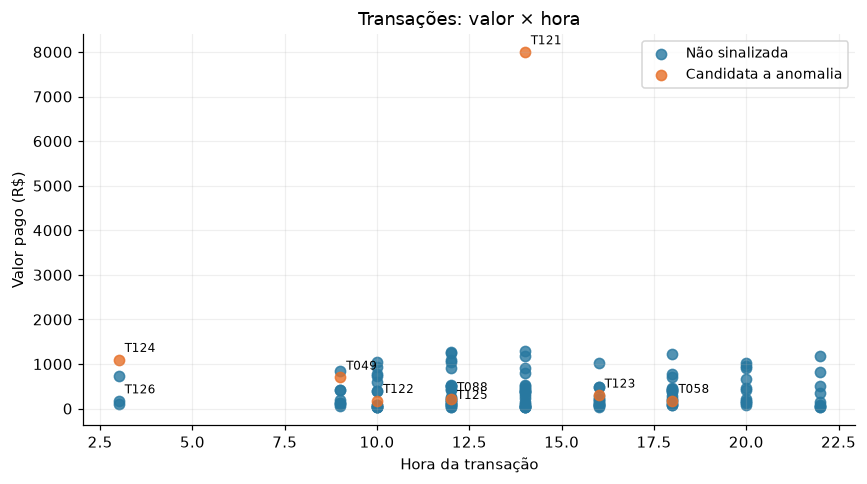

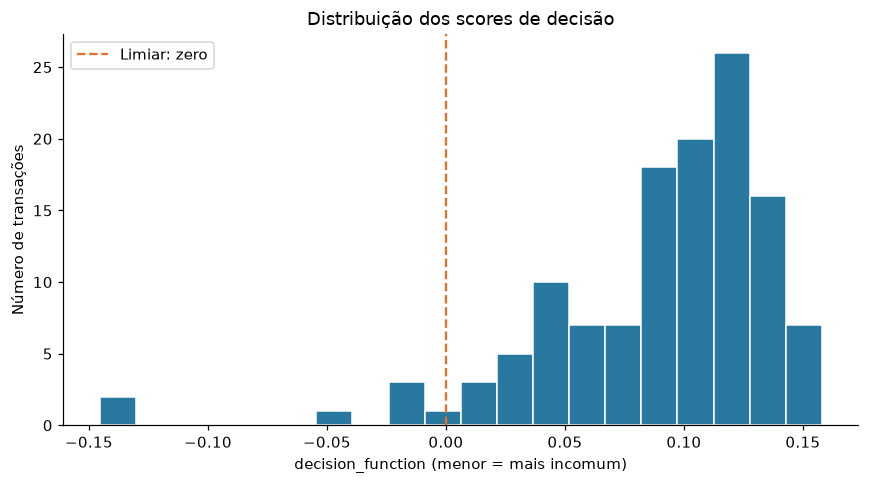

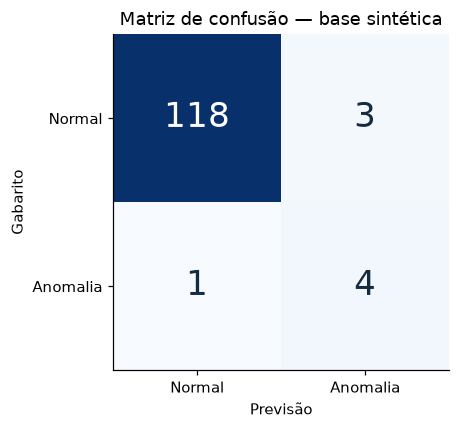

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for flag, cor, nome in [
    (False, "#2878a0", "Não sinalizada"),
    (True, "#e76f28", "Candidata a anomalia"),
]:
    parte = dados[dados["detectada"].eq(flag)]
    ax.scatter(parte["hora"], parte["valor"], c=cor, label=nome, s=45, alpha=0.8)
for _, r in avaliacao.loc[avaliacao["caso_conhecido"] | pred].iterrows():
    ax.annotate(
        r["id_transacao"],
        (r["hora"], r["valor"]),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8,
    )
ax.set(
    xlabel="Hora da transação",
    ylabel="Valor pago (R$)",
    title="Transações: valor × hora",
)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(RESULTADOS / "01_valor_hora.png", dpi=180)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(dados["score_decisao"], bins=20, color="#2878a0", edgecolor="white")
ax.axvline(0, color="#e76f28", linestyle="--", label="Limiar: zero")
ax.set(
    xlabel="decision_function (menor = mais incomum)",
    ylabel="Número de transações",
    title="Distribuição dos scores de decisão",
)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTADOS / "02_scores.png", dpi=180)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(5, 4))
matriz = np.array([[tn, fp], [fn, tp]])
ax.imshow(matriz, cmap="Blues")
for (i, j), v in np.ndenumerate(matriz):
    ax.text(
        j,
        i,
        str(v),
        ha="center",
        va="center",
        fontsize=22,
        color="white" if v > matriz.max() / 2 else "#142c40",
    )
ax.set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=["Normal", "Anomalia"],
    yticklabels=["Normal", "Anomalia"],
    xlabel="Previsão",
    ylabel="Gabarito",
    title="Matriz de confusão — base sintética",
)
fig.tight_layout()
fig.savefig(RESULTADOS / "03_matriz_confusao.png", dpi=180)
plt.show()
plt.close(fig)

## 7. Sensibilidade ao limiar e interpretação
Reutilizamos os mesmos scores e calculamos os limiares percentuais para mostrar o efeito
de `contamination`. Não escolhemos o melhor valor usando o gabarito: mantemos 5% como análise principal.
Aumentar a fração amplia a lista de investigação e pode aumentar tanto a recuperação quanto falsos alertas.

In [8]:
linhas = []
score_samples = modelo.score_samples(X)
for fracao in [0.03, 0.05, 0.08, 0.10]:
    previstos = score_samples < np.percentile(score_samples, 100 * fracao)
    linhas.append(
        {
            "contamination": fracao,
            "sinalizadas": int(previstos.sum()),
            "conhecidas_encontradas": int((previstos & y).sum()),
            "falsos_positivos": int((previstos & ~y).sum()),
        }
    )

sensibilidade = pd.DataFrame(linhas)
print(sensibilidade.to_string(index=False))
sensibilidade.to_csv(RESULTADOS / "sensibilidade.csv", index=False)
print(
    f"\nO modelo sinalizou {pred.sum()} compras, recuperou {tp} de {y.sum()} anomalias conhecidas e produziu {fp} falsos positivos."
)
for _, r in avaliacao.loc[avaliacao["caso_conhecido"]].iterrows():
    print(
        f"{r['id_transacao']}: {'sinalizada' if r['detectada'] else 'não sinalizada'} — {r['descricao']}"
    )
print(
    (
        "T126 é uma compra indevida sem desvio observável: discussão "
        "qualitativa, fora do denominador do recall de anomalias."
    )
)
print(
    (
        "Falsos positivos podem ser compras legítimas com combinações raras. "
        "Conferir produto, promoção e contexto antes de bloquear ou excluir."
    )
)
print(
    (
        "A combinação é explicitada pela razão de preço por categoria; o modelo"
        " não entende sozinho a política comercial."
    )
)
print(
    (
        "Próximos passos: validar com histórico real, separar períodos de "
        "treino e avaliação, testar estabilidade e calibrar o limiar pela "
        "capacidade de investigação."
    )
)

 contamination  sinalizadas  conhecidas_encontradas  falsos_positivos
          0.03            4                       3                 1
          0.05            7                       4                 3
          0.08           10                       4                 6
          0.10           13                       4                 9

O modelo sinalizou 7 compras, recuperou 4 de 5 anomalias conhecidas e produziu 3 falsos positivos.
T121: sinalizada — R$ 8.000 por um item, muito acima do padrão da loja.
T122: sinalizada — 45 itens em uma compra, contra 1 a 5 nas compras usuais.
T123: sinalizada — Desconto de 95%, fora da política simulada de até 15%.
T124: sinalizada — Valor e quantidade dentro das faixas globais, mas R$ 1.100 por um item de papelaria é incompatível com o padrão da categoria.
T125: não sinalizada — R$ 45 por quatro eletrônicos: valor por item muito baixo para a categoria.
T126: não sinalizada — Compra confirmada como indevida no cenário fictício; atributos

## Referências
- Liu, Ting e Zhou (2008), [Isolation Forest](https://doi.org/10.1109/ICDM.2008.17).
- Liu, Ting e Zhou (2012), [Isolation-Based Anomaly Detection](https://doi.org/10.1145/2133360.2133363).
- [Documentação oficial do IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html).
- Metaj (2022), [sistema de detecção de anomalias no CERN OpenStack](https://repository.cern/records/4pbhe-e1w97).
- Hariri, Kind e Brunner, [Extended Isolation Forest](https://arxiv.org/abs/1811.02141).
- Xu et al., [Deep Isolation Forest](https://arxiv.org/abs/2206.06602).